# R-GAT (Relational GAT), 3 layers

**Per-relation parameters with mean aggregation, no HAN.**

## Architecture

```
Layer 1 (per relation):  GATConv_r(768 -> 64, 4 heads, concat=True)
Mean aggregator:         h^1 = (H^1_cites + H^1_cited_by) / 2  (fixed, no learned weights)
ELU + dropout

Layer 2 (per relation):  GATConv_r(256 -> 64, 4 heads, concat=True)
Mean aggregator:         h^2 = (H^2_cites + H^2_cited_by) / 2 + h^1  (residual)
ELU + dropout

Layer 3 (per relation):  GATConv_r(256 -> 256, 1 head)
Mean aggregator:         output = (H^3_cites + H^3_cited_by) / 2
```

3 layers, residual on layer 2, OUTPUT_DIM=256, 4/4/1 heads, 80 epochs, mixed negatives.


## Imports + speed flags

In [1]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from pathlib import Path

from torch_geometric.nn import GATConv

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True

## Reproducibility, device, GPU info

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA B200
VRAM: 191.5 GB


## Configuration

This notebook uses the hetero graph so per-relation GATConvs can index per-relation edge sets. Mean aggregation has no learnable params.


In [3]:
# --- Paths ---
PROCESSED_DIR = Path("./data/processed_v2")
MODEL_OUT_DIR = Path("./models")
PLOTS_OUT_DIR = Path("./data")

# --- Negative strategy ---
NEG_STRATEGY = 'mixed'

# --- Hetero relations ---
RELATIONS = ['cites', 'cited_by']

# --- Encoder (3-layer R-GAT) ---
INPUT_DIM = 768
HIDDEN_DIM = 256
OUTPUT_DIM = 256
GAT_HEADS_LAYER1 = 4
MIDDLE_HEADS = 4
GAT_HEADS_LAYER3 = 1
GAT_NEGATIVE_SLOPE = 0.2
DROPOUT = 0.2
ATTN_DROPOUT = 0.0
USE_RESIDUAL_LAYER2 = True

# --- Decoder ---
DECODER_HIDDEN_DIM = 128
DECODER_DROPOUT = 0.0

# --- Optimization ---
LR = 1e-3
WEIGHT_DECAY = 1e-5
GRAD_CLIP_NORM = 0.0

# --- Training ---
NUM_EPOCHS = 100
BATCH_SIZE = 1024
EVAL_EVERY = 5
GNN_GRAD_SAMPLE_SIZE = 64
EVAL_AUTHOR_BATCH = 256
EVAL_FULLPOOL_BATCH = 16

USE_BFLOAT16 = True
EARLY_STOP_PATIENCE = 5

print(f"Data dir:      {PROCESSED_DIR}")
print(f"Relations:     {RELATIONS}")
print(f"NEG_STRATEGY:  {NEG_STRATEGY}")
print(f"R-GAT-3L: heads_l1={GAT_HEADS_LAYER1}, mid={MIDDLE_HEADS}, l3={GAT_HEADS_LAYER3}")
print(f"Dims:          {INPUT_DIM} -> {HIDDEN_DIM} -> {HIDDEN_DIM} -> {OUTPUT_DIM}")
print(f"Aggregator:    fixed mean (no HAN, no learnable relation weights)")
print(f"Residual L2:   {USE_RESIDUAL_LAYER2}")
print(f"Schedule:      {NUM_EPOCHS} epochs, batch {BATCH_SIZE}, eval every {EVAL_EVERY}")

Data dir:      data/processed_v2
Relations:     ['cites', 'cited_by']
NEG_STRATEGY:  mixed
R-GAT-3L: heads_l1=4, mid=4, l3=1
Dims:          768 -> 256 -> 256 -> 256
Aggregator:    fixed mean (no HAN, no learnable relation weights)
Residual L2:   True
Schedule:      100 epochs, batch 1024, eval every 5


## Step 1 — Load data + pre-cache hetero graphs on GPU + pre-tensorize

In [4]:
train_years = torch.load(PROCESSED_DIR / "train_years.pt", weights_only=False)
metadata = torch.load(PROCESSED_DIR / "metadata.pt", weights_only=False)
val_data = torch.load(PROCESSED_DIR / "val.pt", weights_only=False)
test_data = torch.load(PROCESSED_DIR / "test.pt", weights_only=False)

print(f"Training years ({len(train_years)}): {train_years}")
print(f"Val examples:  {len(val_data['supervision']):,}")
print(f"Test examples: {len(test_data['supervision']):,}")
assert metadata['embed_dim'] == INPUT_DIM

def tensorize_examples(supervision, mode, device):
    for ex in supervision:
        ex['_hist_t'] = torch.tensor(ex['history_locals'], dtype=torch.long, device=device)
        ex['_pos_t']  = torch.tensor(ex['positive_locals'], dtype=torch.long, device=device)
        if mode == 'train':
            ex['_negr_t'] = torch.tensor(ex['negatives_random'], dtype=torch.long, device=device)
            ex['_negh_t'] = torch.tensor(ex['negatives_hard'], dtype=torch.long, device=device)
        else:
            ex['_negm_t'] = torch.tensor(ex['negative_locals_mixed'], dtype=torch.long, device=device)
            if 'known_locals' in ex:
                ex['_known_t'] = torch.tensor(list(ex['known_locals']), dtype=torch.long, device=device)
                ex['_pos_set'] = set(ex['positive_locals'])

def hetero_to_device(g, device):
    g['paper'].x = g['paper'].x.to(device)
    for rel in RELATIONS:
        et = ('paper', rel, 'paper')
        g[et].edge_index = g[et].edge_index.to(device)
    return g

print("\nPre-loading all training years (hetero graphs)...")
all_year_data = {}
t0 = time.time()
for year in train_years:
    yd = torch.load(PROCESSED_DIR / f"train_year_{year}.pt", weights_only=False)
    yd['hetero_graph'] = hetero_to_device(yd['hetero_graph'], device)
    tensorize_examples(yd['supervision'], mode='train', device=device)
    yd.pop('homo_graph', None)  # not needed for R-GAT
    all_year_data[year] = yd
    print(f"  year {year}: {yd['hetero_graph']['paper'].num_nodes:,} papers, "
          f"{len(yd['supervision']):,} examples")
print(f"Loaded {len(all_year_data)} years in {time.time()-t0:.1f}s")

print("\nPreparing val + test...")
val_data['hetero_graph'] = hetero_to_device(val_data['hetero_graph'], device)
tensorize_examples(val_data['supervision'], mode='eval', device=device)
test_data['hetero_graph'] = hetero_to_device(test_data['hetero_graph'], device)
tensorize_examples(test_data['supervision'], mode='eval', device=device)

if torch.cuda.is_available():
    print(f"\nGPU memory after preload: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

def get_edge_index_dict(g, relations=RELATIONS):
    return {rel: g['paper', rel, 'paper'].edge_index for rel in relations}

Training years (12): [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Val examples:  43,562
Test examples: 37,046

Pre-loading all training years (hetero graphs)...
  year 2005: 107,163 papers, 14,780 examples
  year 2006: 125,063 papers, 16,944 examples
  year 2007: 144,229 papers, 19,955 examples
  year 2008: 165,790 papers, 22,485 examples
  year 2009: 189,419 papers, 26,268 examples
  year 2010: 215,312 papers, 29,597 examples
  year 2011: 243,744 papers, 32,787 examples
  year 2012: 274,267 papers, 36,438 examples
  year 2013: 307,407 papers, 39,737 examples
  year 2014: 342,789 papers, 42,423 examples
  year 2015: 379,003 papers, 45,249 examples
  year 2016: 418,317 papers, 45,364 examples
Loaded 12 years in 31.6s

Preparing val + test...

GPU memory after preload: 14.7 GB


## Step 2 — R-GAT 3-layer encoder

Per-layer: one `GATConv` per relation (separate $W_r$ and attention vector $\mathbf{a}_r$). Outputs are aggregated via **fixed mean** — no HAN, no learnable relation weights, no softmax saturation.

Residual on layer 2.


In [5]:
class RGAT3LEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, relations,
                 heads_l1=4, middle_heads=4, heads_l3=1,
                 dropout=0.2, attn_dropout=0.0,
                 negative_slope=0.2, use_residual_layer2=True):
        super().__init__()
        assert hidden_dim % heads_l1 == 0
        assert hidden_dim % middle_heads == 0
        per_head_l1 = hidden_dim // heads_l1
        per_head_mid = hidden_dim // middle_heads
        self.relations = list(relations)
        self.dropout = dropout
        self.use_residual_layer2 = use_residual_layer2

        def make_per_rel(in_d, out_d, heads, concat):
            return nn.ModuleDict({
                rel: GATConv(in_d, out_d, heads=heads, concat=concat,
                             negative_slope=negative_slope, dropout=attn_dropout)
                for rel in self.relations
            })

        self.conv1 = make_per_rel(input_dim, per_head_l1, heads_l1, concat=True)
        self.conv2 = make_per_rel(hidden_dim, per_head_mid, middle_heads, concat=True)
        self.conv3 = make_per_rel(hidden_dim, output_dim, heads_l3, concat=(heads_l3 > 1))

    def _mean_aggregate(self, conv_dict, h, edge_index_dict):
        """Per-relation messages aggregated via fixed equal-weight mean (no HAN)."""
        per_rel = [conv_dict[rel](h, edge_index_dict[rel]) for rel in self.relations]
        return torch.stack(per_rel, dim=0).mean(dim=0)

    def forward(self, x, edge_index_dict):
        h1 = self._mean_aggregate(self.conv1, x, edge_index_dict)
        h1 = F.elu(h1); h1 = F.dropout(h1, p=self.dropout, training=self.training)

        h2 = self._mean_aggregate(self.conv2, h1, edge_index_dict)
        if self.use_residual_layer2:
            h2 = h2 + h1
        h2 = F.elu(h2); h2 = F.dropout(h2, p=self.dropout, training=self.training)

        return self._mean_aggregate(self.conv3, h2, edge_index_dict)

# Sanity
_te = RGAT3LEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, middle_heads=MIDDLE_HEADS, heads_l3=GAT_HEADS_LAYER3,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, use_residual_layer2=USE_RESIDUAL_LAYER2,
).to(device)
_yd = all_year_data[train_years[0]]
_eid = get_edge_index_dict(_yd['hetero_graph'])
_te.eval()
with torch.no_grad():
    _out = _te(_yd['hetero_graph']['paper'].x, _eid)
assert _out.shape == (_yd['hetero_graph']['paper'].num_nodes, OUTPUT_DIM)
assert not torch.isnan(_out).any() and not torch.isinf(_out).any()
print(f"Encoder out: {_out.shape}")
print(f"Encoder params: {sum(p.numel() for p in _te.parameters()):,}")
print("[PASS] RGAT3LEncoder")
del _te, _out

Encoder out: torch.Size([107163, 256])
Encoder params: 659,968
[PASS] RGAT3LEncoder


## Step 3 — Decoder + utilities (mean-pool, BPR, neg helper)

In [6]:
class MLPDecoder(nn.Module):
    def __init__(self, emb_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(2 * emb_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, author_emb, paper_emb):
        combined = torch.cat([author_emb, paper_emb], dim=-1)
        h = F.relu(self.fc1(combined))
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.fc2(h).squeeze(-1)

def compute_author_embeddings_from_tensors(paper_embeddings, supervision_examples):
    return torch.stack([paper_embeddings[ex['_hist_t']].mean(dim=0) for ex in supervision_examples])

def bpr_loss(pos_scores, neg_scores):
    diff = pos_scores.unsqueeze(1) - neg_scores.unsqueeze(0)
    return -F.logsigmoid(diff).mean()

def get_train_negatives_t(ex, strategy):
    if strategy == 'random':
        return ex['_negr_t']
    if strategy == 'hard':
        return ex['_negh_t']
    n = ex['_negr_t'].shape[0]
    half = n // 2
    return torch.cat([ex['_negr_t'][:half], ex['_negh_t'][:n - half]])

## Step 4 — Train one year (optimized, hetero-graph forward)

In [7]:
def train_one_year_fast(encoder, decoder, optimizer, year_data, device,
                        batch_size=1024, gnn_sample_size=64, grad_clip=0.0,
                        neg_strategy='mixed', use_amp=True):
    encoder.train(); decoder.train()
    g = year_data['hetero_graph']
    eid = get_edge_index_dict(g)
    examples = year_data['supervision']
    if not examples:
        return 0.0

    amp_ctx = torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16) if use_amp else \
              torch.amp.autocast(device_type='cuda', enabled=False)

    with torch.no_grad():
        with amp_ctx:
            paper_embs_detached = encoder(g['paper'].x, eid).float()
    paper_embs_detached = paper_embs_detached.detach()

    indices = list(range(len(examples)))
    random.shuffle(indices)
    total_loss, num_batches = 0.0, 0

    for batch_start in range(0, len(indices), batch_size):
        bidx = indices[batch_start:batch_start + batch_size]
        bex = [examples[i] for i in bidx]
        author_embs = compute_author_embeddings_from_tensors(paper_embs_detached, bex)

        all_a, all_p, bounds = [], [], []
        offset = 0
        for i, ex in enumerate(bex):
            negs_t = get_train_negatives_t(ex, neg_strategy)
            if negs_t.numel() == 0:
                continue
            n_pos, n_neg = ex['_pos_t'].shape[0], negs_t.shape[0]
            a = author_embs[i]
            all_a.append(a.unsqueeze(0).expand(n_pos + n_neg, -1))
            all_p.append(torch.cat([paper_embs_detached[ex['_pos_t']], paper_embs_detached[negs_t]], dim=0))
            bounds.append((offset, n_pos, n_neg))
            offset += n_pos + n_neg
        if not all_a:
            continue

        flat_a = torch.cat(all_a, dim=0)
        flat_p = torch.cat(all_p, dim=0)

        with amp_ctx:
            scores = decoder(flat_a, flat_p)
            batch_loss = torch.tensor(0.0, device=device)
            for start, n_pos, n_neg in bounds:
                ps = scores[start:start + n_pos]
                ns = scores[start + n_pos:start + n_pos + n_neg]
                batch_loss = batch_loss + bpr_loss(ps, ns)
            batch_loss = batch_loss / len(bounds)

        optimizer.zero_grad()
        batch_loss.backward()
        if grad_clip > 0:
            torch.nn.utils.clip_grad_norm_(
                list(encoder.parameters()) + list(decoder.parameters()),
                max_norm=grad_clip,
            )
        optimizer.step()
        total_loss += float(batch_loss.detach())
        num_batches += 1

    sample = random.sample(examples, min(gnn_sample_size, len(examples)))
    with amp_ctx:
        pe_grad = encoder(g['paper'].x, eid)
        ae = compute_author_embeddings_from_tensors(pe_grad, sample)
        gnn_loss = torch.tensor(0.0, device=device)
        for i, ex in enumerate(sample):
            negs_t = get_train_negatives_t(ex, neg_strategy)
            if negs_t.numel() == 0:
                continue
            a = ae[i]
            ps = decoder(a.unsqueeze(0).expand(ex['_pos_t'].shape[0], -1), pe_grad[ex['_pos_t']])
            ns = decoder(a.unsqueeze(0).expand(negs_t.shape[0], -1), pe_grad[negs_t])
            gnn_loss = gnn_loss + bpr_loss(ps, ns)
        gnn_loss = gnn_loss / max(len(sample), 1)

    optimizer.zero_grad()
    gnn_loss.backward()
    if grad_clip > 0:
        torch.nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(decoder.parameters()),
            max_norm=grad_clip,
        )
    optimizer.step()

    return total_loss / max(num_batches, 1)

## Step 5 — Batched 1K mixed eval

In [8]:
@torch.no_grad()
def evaluate_fast(encoder, decoder, eval_data, device, author_batch_size=256):
    encoder.eval(); decoder.eval()
    g = eval_data['hetero_graph']
    eid = get_edge_index_dict(g)
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}

    paper_embs = encoder(g['paper'].x, eid)
    M = len(examples)

    author_embs = torch.stack([paper_embs[ex['_hist_t']].mean(dim=0) for ex in examples])
    n_pos_arr = [ex['_pos_t'].shape[0] for ex in examples]
    cand_t_list = [torch.cat([ex['_pos_t'], ex['_negm_t']]) for ex in examples]
    max_len = max(c.shape[0] for c in cand_t_list)

    cand_ids = torch.zeros(M, max_len, dtype=torch.long, device=device)
    valid = torch.zeros(M, max_len, dtype=torch.bool, device=device)
    pos_mask = torch.zeros(M, max_len, dtype=torch.bool, device=device)
    for i, (c, np_) in enumerate(zip(cand_t_list, n_pos_arr)):
        L = c.shape[0]
        cand_ids[i, :L] = c
        valid[i, :L] = True
        pos_mask[i, :np_] = True

    D = paper_embs.shape[1]
    hits10 = torch.zeros(M, device=device)
    mrrs = torch.zeros(M, device=device)

    for bs in range(0, M, author_batch_size):
        be = min(bs + author_batch_size, M)
        b = be - bs
        a = author_embs[bs:be]
        cids = cand_ids[bs:be]
        cembs = paper_embs[cids]
        a_exp = a.unsqueeze(1).expand(-1, max_len, -1)
        flat_a = a_exp.reshape(-1, D)
        flat_c = cembs.reshape(-1, D)
        scores = decoder(flat_a, flat_c).reshape(b, max_len)
        scores = scores.masked_fill(~valid[bs:be], float('-inf'))

        _, ranked = scores.sort(dim=-1, descending=True)
        is_pos_at_rank = torch.gather(pos_mask[bs:be], 1, ranked)
        any_pos = is_pos_at_rank.any(dim=-1)
        first_pos = is_pos_at_rank.float().argmax(dim=-1)
        best_rank = torch.where(any_pos, first_pos + 1, torch.tensor(max_len + 1, device=device))
        hits10[bs:be] = (best_rank <= 10).float()
        mrrs[bs:be] = torch.where(any_pos, 1.0 / best_rank.float(), torch.zeros_like(best_rank.float()))

    return {'hits@10': float(hits10.mean()), 'mrr': float(mrrs.mean()), 'num_authors': M}

## Step 6 — Batched full-pool eval

In [9]:
@torch.no_grad()
def evaluate_full_pool_fast(encoder, decoder, eval_data, device, author_batch_size=16):
    encoder.eval(); decoder.eval()
    examples = eval_data['supervision']
    if not examples:
        return {'hits@10': 0.0, 'mrr': 0.0, 'num_authors': 0}
    if '_known_t' not in examples[0]:
        raise KeyError("Full-pool eval requires 'known_locals'.")

    g = eval_data['hetero_graph']
    eid = get_edge_index_dict(g)
    paper_embs = encoder(g['paper'].x, eid)
    N, D = paper_embs.shape
    M = len(examples)

    author_embs = torch.stack([paper_embs[ex['_hist_t']].mean(dim=0) for ex in examples])
    hits10 = torch.zeros(M, device=device)
    mrrs = torch.zeros(M, device=device)

    for bs in range(0, M, author_batch_size):
        be = min(bs + author_batch_size, M)
        b = be - bs
        a = author_embs[bs:be]
        a_exp = a.unsqueeze(1).expand(-1, N, -1).reshape(-1, D)
        p_exp = paper_embs.unsqueeze(0).expand(b, -1, -1).reshape(-1, D)
        scores = decoder(a_exp, p_exp).reshape(b, N)

        for j, gi in enumerate(range(bs, be)):
            ex = examples[gi]
            known_t = ex['_known_t']
            pos_set = ex['_pos_set']
            mask_idx = known_t[~torch.tensor([k.item() in pos_set for k in known_t], device=device)] if known_t.numel() else known_t
            if mask_idx.numel() > 0:
                scores[j, mask_idx] = float('-inf')

        for j, gi in enumerate(range(bs, be)):
            ex = examples[gi]
            pos_t = ex['_pos_t']
            row = scores[j]
            _, ranked = row.sort(descending=True)
            in_pos = torch.isin(ranked, pos_t)
            nz = in_pos.nonzero()
            if nz.numel() > 0:
                best = nz[0].item() + 1
                hits10[gi] = 1.0 if best <= 10 else 0.0
                mrrs[gi] = 1.0 / best
    return {'hits@10': float(hits10.mean()), 'mrr': float(mrrs.mean()), 'num_authors': M}

## Step 7 — Initialize + training loop with timing + early stopping

In [10]:
encoder = RGAT3LEncoder(
    INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, RELATIONS,
    heads_l1=GAT_HEADS_LAYER1, middle_heads=MIDDLE_HEADS, heads_l3=GAT_HEADS_LAYER3,
    dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
    negative_slope=GAT_NEGATIVE_SLOPE, use_residual_layer2=USE_RESIDUAL_LAYER2,
).to(device)
decoder = MLPDecoder(OUTPUT_DIM, DECODER_HIDDEN_DIM, DECODER_DROPOUT).to(device)
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(decoder.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY,
)
n_enc = sum(p.numel() for p in encoder.parameters())
n_dec = sum(p.numel() for p in decoder.parameters())
print(f"Encoder params: {n_enc:,}")
print(f"Decoder params: {n_dec:,}")
print(f"Total:          {n_enc + n_dec:,}")

train_losses, val_hits, val_mrrs, eval_epochs = [], [], [], []
best_val_mrr = -1.0
best_epoch = 0
best_encoder_state = None
best_decoder_state = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    t_epoch = time.time()
    epoch_losses = []
    for year in train_years:
        l = train_one_year_fast(
            encoder, decoder, optimizer, all_year_data[year], device,
            batch_size=BATCH_SIZE,
            gnn_sample_size=GNN_GRAD_SAMPLE_SIZE,
            grad_clip=GRAD_CLIP_NORM,
            neg_strategy=NEG_STRATEGY,
            use_amp=USE_BFLOAT16,
        )
        epoch_losses.append(l)
    avg = float(np.mean(epoch_losses))
    train_losses.append(avg)
    epoch_dur = time.time() - t_epoch

    if epoch % EVAL_EVERY == 0 or epoch == NUM_EPOCHS:
        t_eval = time.time()
        v = evaluate_fast(encoder, decoder, val_data, device, EVAL_AUTHOR_BATCH)
        eval_dur = time.time() - t_eval
        val_hits.append(v['hits@10']); val_mrrs.append(v['mrr']); eval_epochs.append(epoch)

        improved = v['mrr'] > best_val_mrr
        if improved:
            best_val_mrr = v['mrr']
            best_epoch = epoch
            best_encoder_state = {k: vv.detach().clone() for k, vv in encoder.state_dict().items()}
            best_decoder_state = {k: vv.detach().clone() for k, vv in decoder.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        marker = " *" if improved else ""
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f} | "
              f"Val H@10 {v['hits@10']:.4f} | Val MRR {v['mrr']:.4f}{marker} | "
              f"train {epoch_dur:.1f}s, eval {eval_dur:.1f}s")

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n[Early stop] no val MRR improvement for {EARLY_STOP_PATIENCE} evals. "
                  f"Best: epoch {best_epoch}, MRR {best_val_mrr:.4f}.")
            break
    else:
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Loss {avg:.4f} | train {epoch_dur:.1f}s")

Encoder params: 659,968
Decoder params: 65,793
Total:          725,761
Epoch   1/100 | Loss 0.6275 | train 45.9s
Epoch   2/100 | Loss 0.5904 | train 46.0s
Epoch   3/100 | Loss 0.5708 | train 48.1s
Epoch   4/100 | Loss 0.5506 | train 46.1s
Epoch   5/100 | Loss 0.5219 | Val H@10 0.3675 | Val MRR 0.1606 * | train 46.0s, eval 1.6s
Epoch   6/100 | Loss 0.4984 | train 46.1s
Epoch   7/100 | Loss 0.4761 | train 48.4s
Epoch   8/100 | Loss 0.4492 | train 46.4s
Epoch   9/100 | Loss 0.4250 | train 46.7s
Epoch  10/100 | Loss 0.4025 | Val H@10 0.4913 | Val MRR 0.2447 * | train 46.7s, eval 1.6s
Epoch  11/100 | Loss 0.3843 | train 46.1s
Epoch  12/100 | Loss 0.3597 | train 49.0s
Epoch  13/100 | Loss 0.3297 | train 46.4s
Epoch  14/100 | Loss 0.3223 | train 46.4s
Epoch  15/100 | Loss 0.3107 | Val H@10 0.6173 | Val MRR 0.3519 * | train 46.6s, eval 1.6s
Epoch  16/100 | Loss 0.2981 | train 48.0s
Epoch  17/100 | Loss 0.2929 | train 46.2s
Epoch  18/100 | Loss 0.2869 | train 46.1s
Epoch  19/100 | Loss 0.2822 |

## Step 8 — Restore checkpoint, plot, test


Restored best checkpoint (epoch 80, val MRR 0.4864)


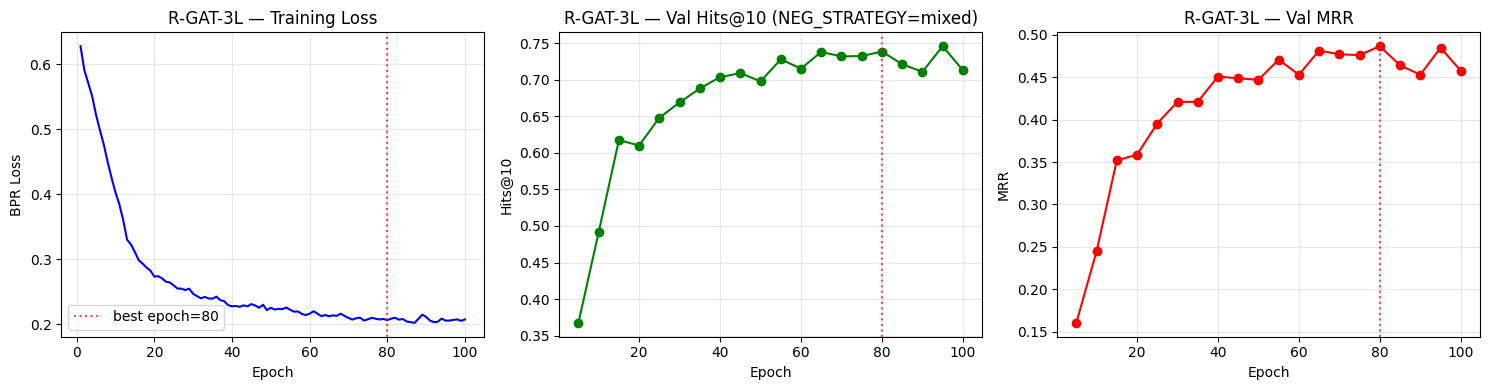

R-GAT v2 3-layer (mean aggregator, NEG_STRATEGY=mixed, best epoch 80) — TEST

[1K mixed pool, 50/50 hard/random]  (1.3s)
  Hits@10: 0.7538
  MRR:     0.5083

[Full pool — every paper in the pre-test graph]  (115.6s)
  Hits@10: 0.0877
  MRR:     0.0390

--- Comparison context ---
  GAT-3L (homogeneous, full pool): 0.0879 (2-seed mean)
  HetGAT-3L (HAN, full pool):       0.0507 (single seed)


In [11]:
import matplotlib.pyplot as plt

if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    decoder.load_state_dict(best_decoder_state)
    print(f"Restored best checkpoint (epoch {best_epoch}, val MRR {best_val_mrr:.4f})")

PLOTS_OUT_DIR.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(range(1, len(train_losses) + 1), train_losses, 'b-')
axes[0].axvline(best_epoch, color='red', linestyle=':', alpha=0.7, label=f'best epoch={best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BPR Loss')
axes[0].set_title('R-GAT-3L — Training Loss'); axes[0].grid(True, alpha=0.3); axes[0].legend()
axes[1].plot(eval_epochs, val_hits, 'g-o')
axes[1].axvline(best_epoch, color='red', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Hits@10')
axes[1].set_title(f'R-GAT-3L — Val Hits@10 (NEG_STRATEGY={NEG_STRATEGY})'); axes[1].grid(True, alpha=0.3)
axes[2].plot(eval_epochs, val_mrrs, 'r-o')
axes[2].axvline(best_epoch, color='red', linestyle=':', alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('MRR')
axes[2].set_title('R-GAT-3L — Val MRR'); axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PLOTS_OUT_DIR / f'rgat_v2_3layer_training_{NEG_STRATEGY}.png'), dpi=100, bbox_inches='tight')
plt.show()

t0 = time.time()
test_1k = evaluate_fast(encoder, decoder, test_data, device, EVAL_AUTHOR_BATCH)
t_1k = time.time() - t0
t0 = time.time()
test_full = evaluate_full_pool_fast(encoder, decoder, test_data, device, EVAL_FULLPOOL_BATCH)
t_full = time.time() - t0

print("=" * 60)
print(f"R-GAT v2 3-layer (mean aggregator, NEG_STRATEGY={NEG_STRATEGY}, best epoch {best_epoch}) — TEST")
print("=" * 60)
print(f"\n[1K mixed pool, 50/50 hard/random]  ({t_1k:.1f}s)")
print(f"  Hits@10: {test_1k['hits@10']:.4f}")
print(f"  MRR:     {test_1k['mrr']:.4f}")
print(f"\n[Full pool — every paper in the pre-test graph]  ({t_full:.1f}s)")
print(f"  Hits@10: {test_full['hits@10']:.4f}")
print(f"  MRR:     {test_full['mrr']:.4f}")
print("\n--- Comparison context ---")
print(f"  GAT-3L (homogeneous, full pool): 0.0879 (2-seed mean)")
print(f"  HetGAT-3L (HAN, full pool):       0.0507 (single seed)")

## Step 9 — Save

In [12]:
MODEL_OUT_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODEL_OUT_DIR / f"rgat_v2_3layer_{NEG_STRATEGY}.pt"

torch.save({
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'config': {
        'arch': '3-layer R-GAT (per-relation GATConv + fixed mean aggregation, no HAN)',
        'input_dim': INPUT_DIM, 'hidden_dim': HIDDEN_DIM, 'output_dim': OUTPUT_DIM,
        'relations': RELATIONS,
        'heads_l1': GAT_HEADS_LAYER1, 'middle_heads': MIDDLE_HEADS, 'heads_l3': GAT_HEADS_LAYER3,
        'gat_negative_slope': GAT_NEGATIVE_SLOPE,
        'dropout': DROPOUT, 'attn_dropout': ATTN_DROPOUT,
        'use_residual_layer2': USE_RESIDUAL_LAYER2,
        'decoder_hidden_dim': DECODER_HIDDEN_DIM, 'decoder_dropout': DECODER_DROPOUT,
        'lr': LR, 'weight_decay': WEIGHT_DECAY, 'grad_clip_norm': GRAD_CLIP_NORM,
        'num_epochs': NUM_EPOCHS, 'best_epoch': best_epoch,
        'batch_size': BATCH_SIZE, 'gnn_grad_sample_size': GNN_GRAD_SAMPLE_SIZE,
        'neg_strategy': NEG_STRATEGY, 'use_bfloat16': USE_BFLOAT16,
        'early_stop_patience': EARLY_STOP_PATIENCE,
        'seed': SEED,
    },
    'val_best': {'hits@10': max(val_hits) if val_hits else 0.0, 'mrr': best_val_mrr, 'epoch': best_epoch},
    'test_1k_mixed': test_1k,
    'test_full_pool': test_full,
    'train_losses': train_losses,
    'val_hits': val_hits, 'val_mrrs': val_mrrs, 'eval_epochs': eval_epochs,
    'data_version': 'v2',
    'fos_level': metadata.get('fos_level'),
}, save_path)
print(f"Saved {save_path}")

Saved models/rgat_v2_3layer_mixed.pt


## Summary

Saved test numbers and training curves are persisted to disk for downstream reporting.
